In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'xapi-edu-data' dataset.
Path to dataset files: /kaggle/input/xapi-edu-data


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os

csv_file_path = os.path.join(path, 'xAPI-Edu-Data.csv')
df = pd.read_csv(csv_file_path)

In [6]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [7]:
df.shape

(480, 17)

In [8]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [10]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [11]:
# EDA
# 1 check null values
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [12]:
# 2 check for target variable
df['Class'].value_counts()

,count
Class,
M,211
H,142
L,127


<Axes: xlabel='Class', ylabel='count'>

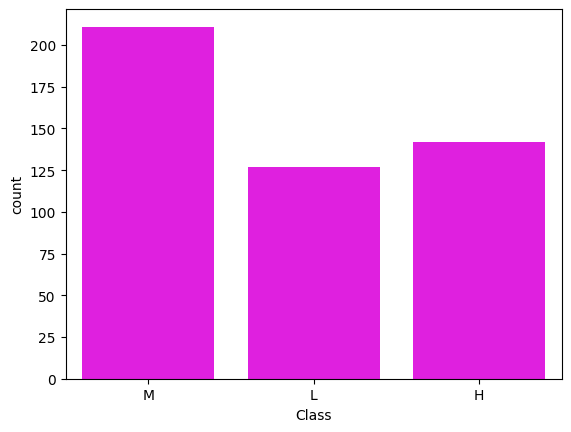

In [13]:
# Data type ?
# classification -> class imbalance
sns.countplot(x=df['Class'],color='magenta')

In [14]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
M,43.958333
H,29.583333
L,26.458333


<Axes: xlabel='Class', ylabel='Count'>

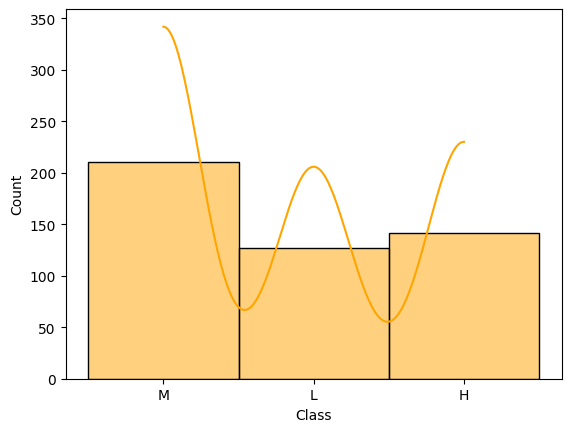

In [15]:
#  EDA
sns.histplot(x=df['Class'],kde=True,color='Orange')

In [16]:
df.duplicated().sum()

np.int64(2)

In [17]:
df.drop_duplicates()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L
476,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M
477,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,S,Father,55,74,25,29,No,Bad,Under-7,M
478,F,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L


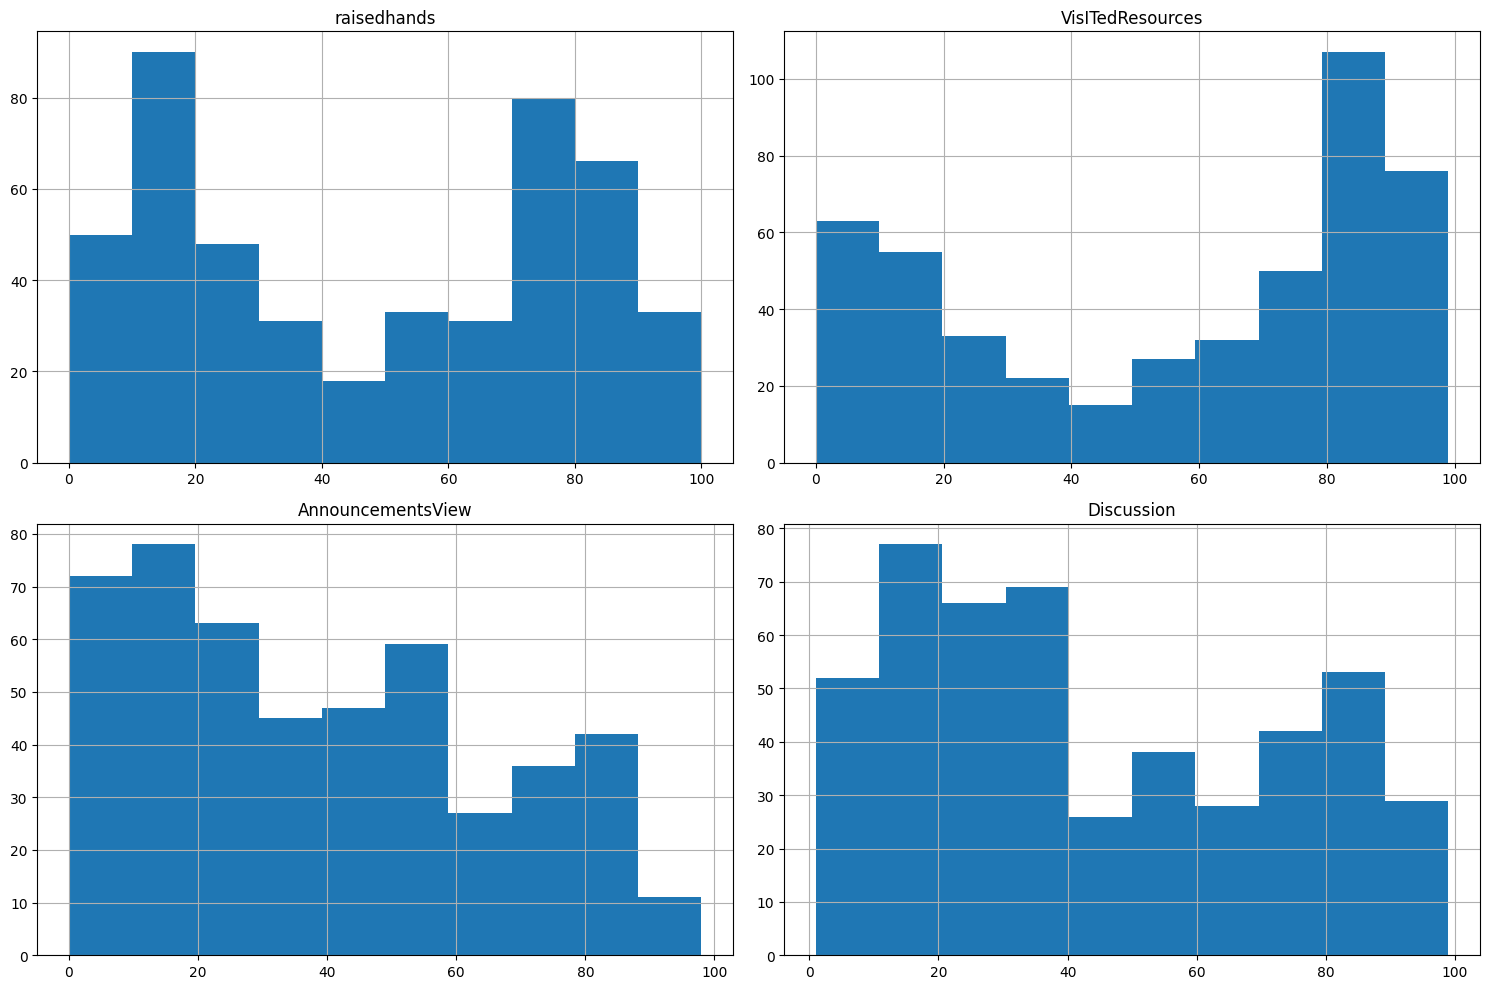

In [18]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

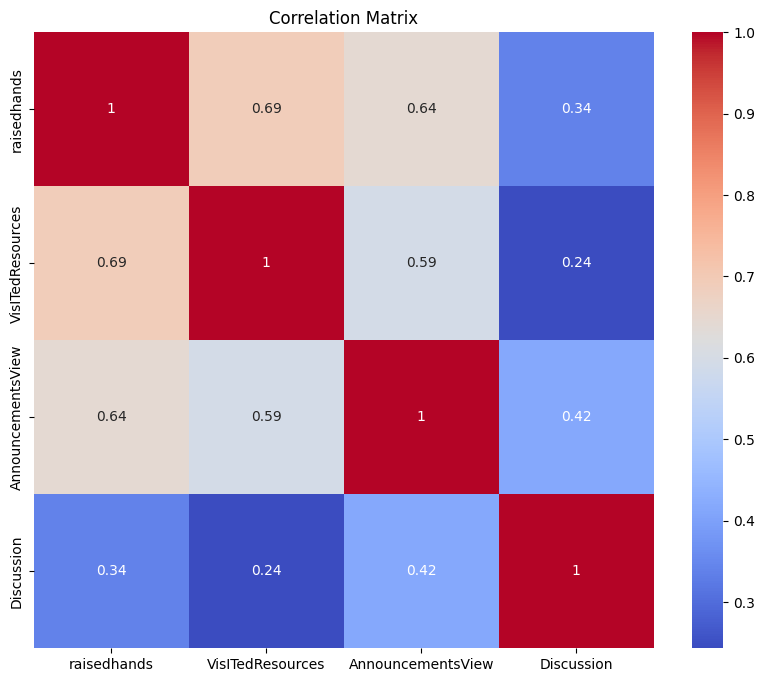

In [19]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

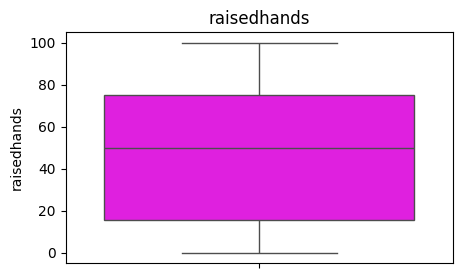

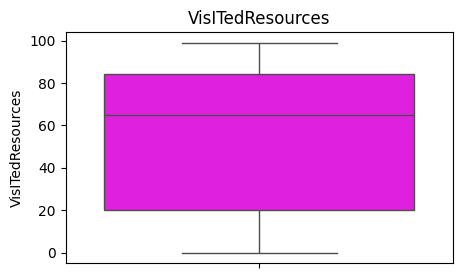

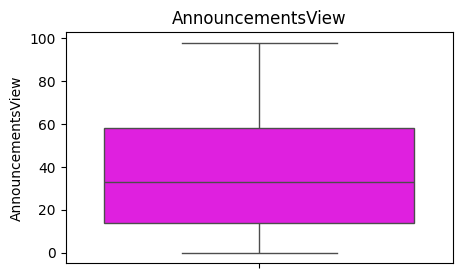

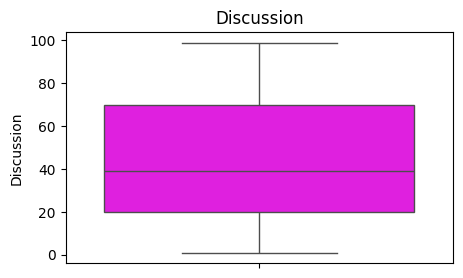

In [20]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(df[col],color='magenta')
    plt.title(col)
    plt.show()

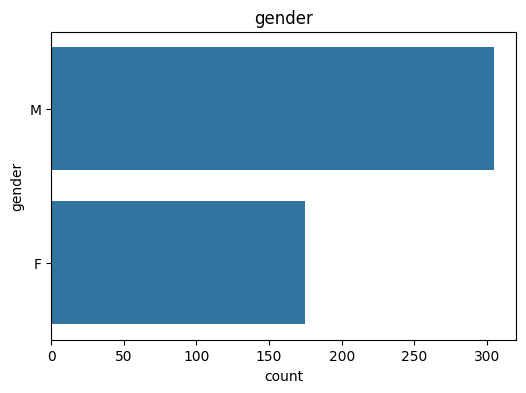

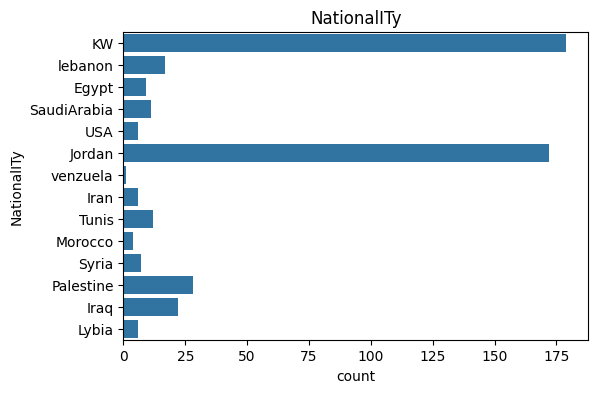

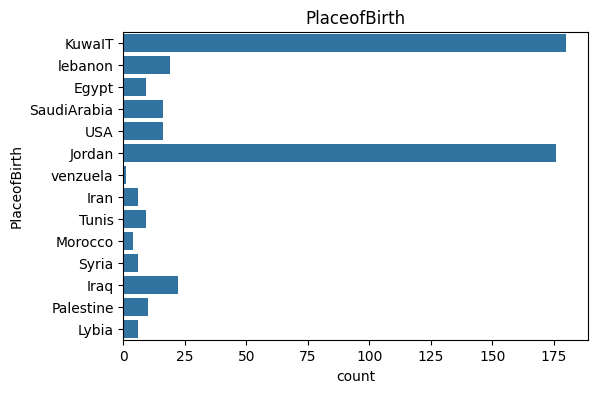

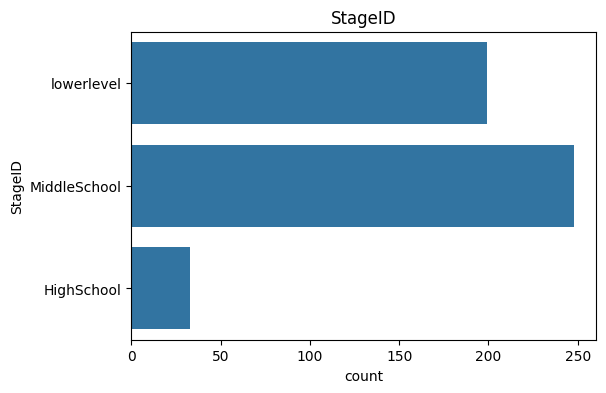

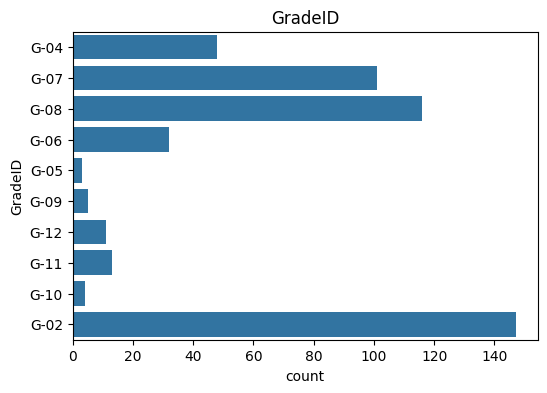

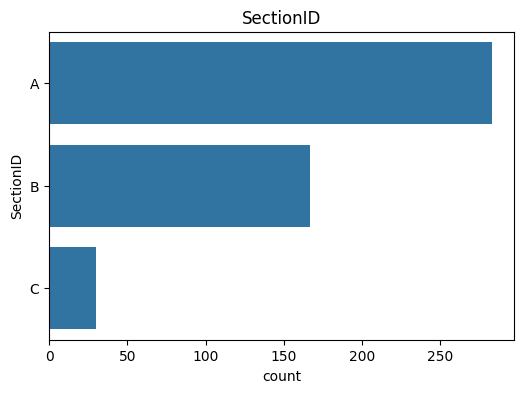

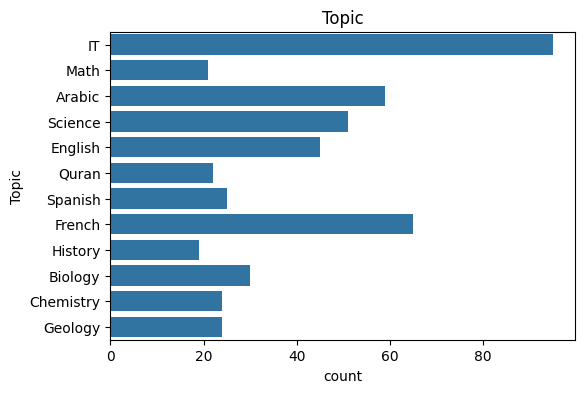

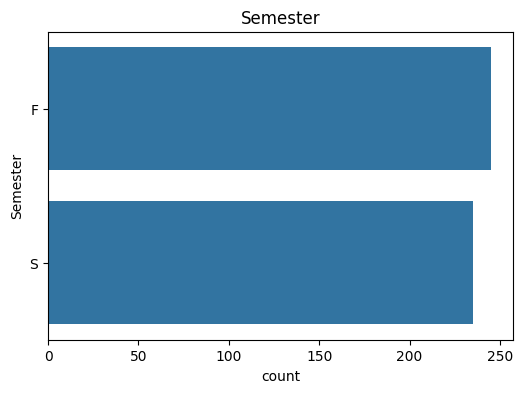

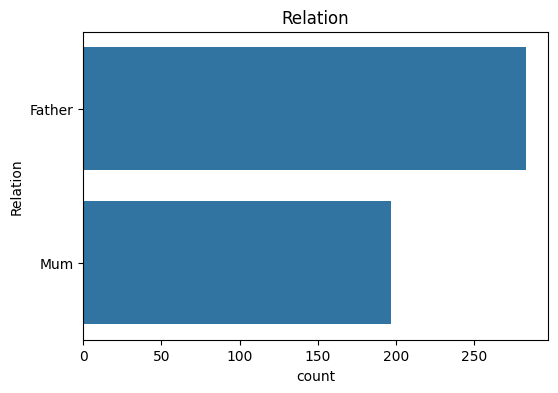

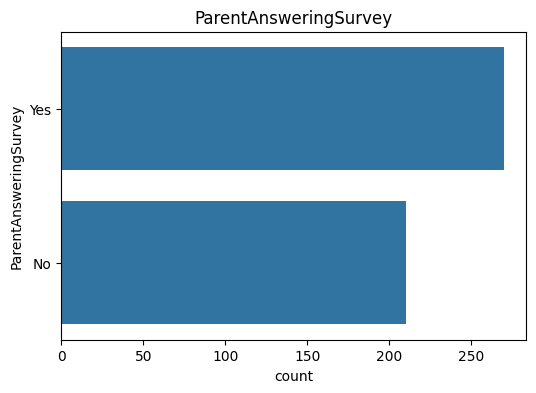

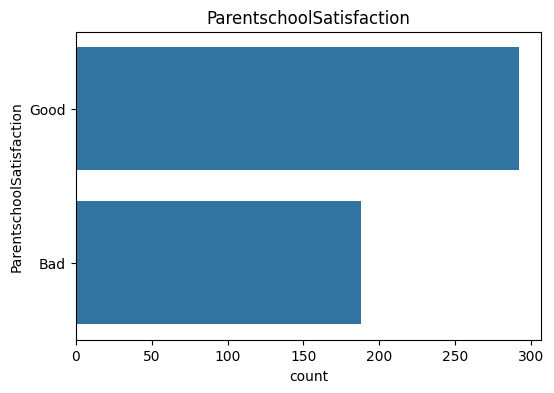

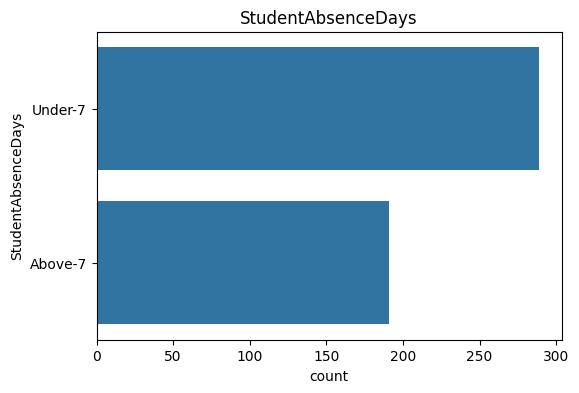

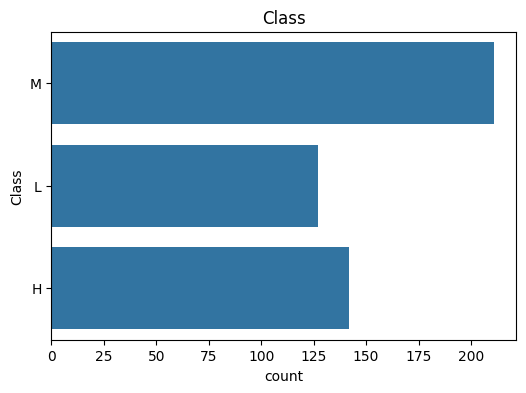

In [21]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(df[col])
    plt.title(col)
    plt.show()

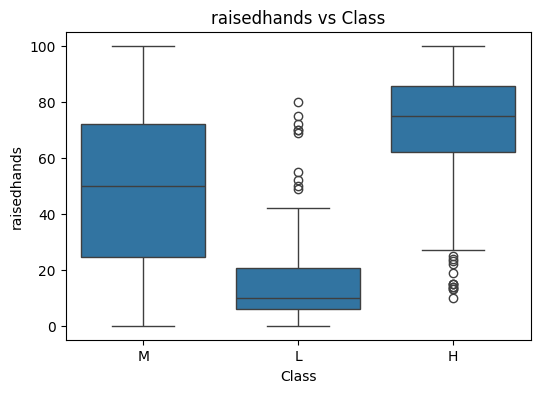

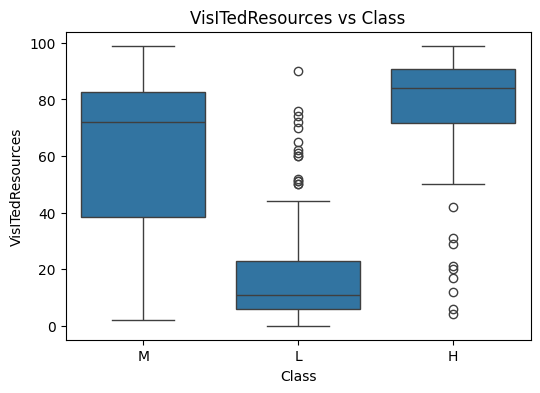

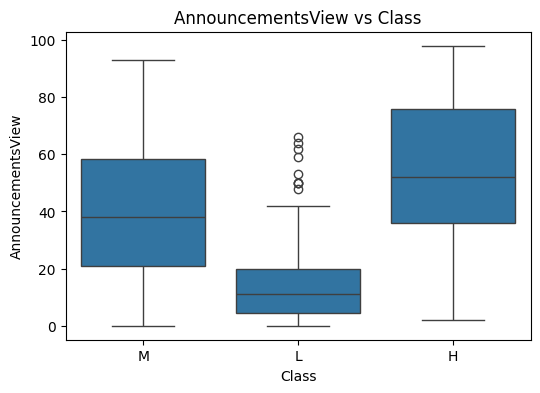

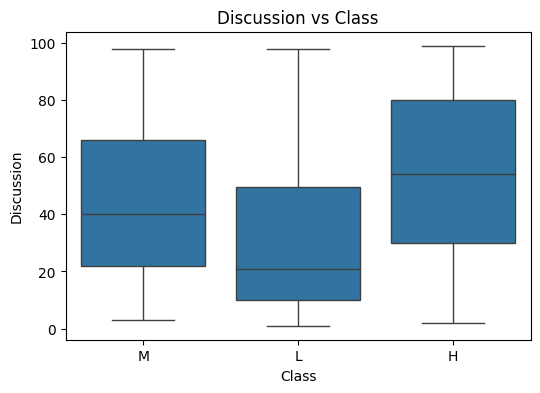

In [22]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Class',y=col,data=df)
    plt.title(f'{col} vs Class')
    plt.show()

In [23]:
# Encoding objects
cat_cols = df.select_dtypes(include='object').columns.to_list()
cat_cols.remove('Class')

df = pd.get_dummies(df,columns=cat_cols)

In [24]:
df['Class'] = df['Class'].map({"M":0,"L":1,"H":2})

In [25]:
df.head()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,Class,gender_F,gender_M,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,...,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7
0,15,16,2,20,0,False,True,False,False,False,...,True,False,True,False,False,True,False,True,False,True
1,20,20,3,25,0,False,True,False,False,False,...,True,False,True,False,False,True,False,True,False,True
2,10,7,0,30,1,False,True,False,False,False,...,True,False,True,False,True,False,True,False,True,False
3,30,25,5,35,1,False,True,False,False,False,...,True,False,True,False,True,False,True,False,True,False
4,40,50,12,50,0,False,True,False,False,False,...,True,False,True,False,True,False,True,False,True,False


In [26]:
# Model building
# KNN Classification
# KNN is a distance based algo , therefore standard scalar is to be used here


In [27]:
# Let's split X and y variables
X = df.drop('Class',axis=1)
y= df['Class']

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Standard scaling ----  to avoid data leakage
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [30]:
# mean = 0, std = 1
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [31]:
# model build, train , Predict, evaluate

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [33]:
score =[]
train_test=[] # we are storing accuracy for each k value (1 to 20)
for k in range (1,21):
  knn = KNeighborsClassifier(n_neighbors = k)
  knn.fit(X_train,y_train) #Training
  y_pred = knn.predict(X_test) #Predictions

  accuracy = accuracy_score(y_test,y_pred)  #testing accuracy
  train = accuracy_score(y_train,knn.predict(X_train))  #training accuracy

  train_test.append(train)
  score.append(accuracy)


In [34]:
score,train_test

([0.6875,
  0.6458333333333334,
  0.6354166666666666,
  0.6041666666666666,
  0.6354166666666666,
  0.6354166666666666,
  0.6458333333333334,
  0.6145833333333334,
  0.6145833333333334,
  0.5729166666666666,
  0.6354166666666666,
  0.5833333333333334,
  0.625,
  0.6041666666666666,
  0.6354166666666666,
  0.5729166666666666,
  0.6041666666666666,
  0.6145833333333334,
  0.6041666666666666,
  0.59375],
 [1.0,
  0.84375,
  0.8255208333333334,
  0.7421875,
  0.7369791666666666,
  0.7317708333333334,
  0.7265625,
  0.703125,
  0.7161458333333334,
  0.7057291666666666,
  0.6796875,
  0.6822916666666666,
  0.6692708333333334,
  0.6822916666666666,
  0.6822916666666666,
  0.6822916666666666,
  0.6770833333333334,
  0.6901041666666666,
  0.6666666666666666,
  0.6770833333333334])

In [35]:
model = KNeighborsClassifier(n_neighbors=11)

model.fit(X_train,y_train)  # training KNN model


KNeighborsClassifier(n_neighbors=11)

In [36]:
y_pred = model.predict(X_test)

In [37]:
accuracy_score(y_test,y_pred)   #testing accuracy

0.6354166666666666

In [38]:

accuracy_score(y_train,model.predict(X_train))   # training accuracy

0.6796875

<Axes: >

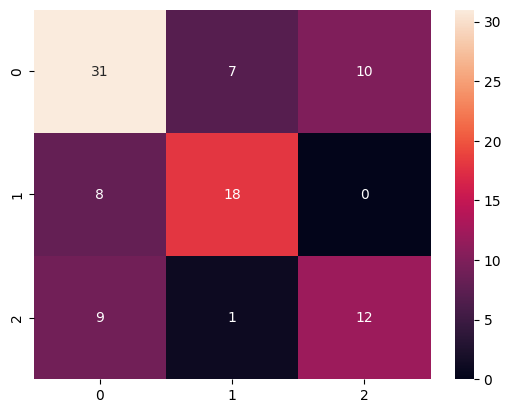

In [39]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot =True)

In [41]:
import joblib
joblib.dump(model,'model.pkl')

['model.pkl']